In [1]:
import pandas as pd
import numpy as np

table1_cols = ["summary_id" ,"pickDate", "count", "itemCode", "itemDescription", "pickQty", "ordQty", "pickedStorageBin", "pickerId", "pickHeNo", "storageSectionId", "totalTimeSeconds", "perQtyTime"]
table2_cols = ["space_id", "st_sec_id", "totalCount", "usedCount", "createdDate", "utilization", "itemCode"]

# =====================================================================
# 1. LOAD THE RAW DATA & PARSE DATES
# =====================================================================
table1 = pd.read_csv('/home/adityaa/Desktop/internship/data/tbl_pick_summary.csv', header = None, names = table1_cols)
table2 = pd.read_csv('/home/adityaa/Desktop/internship/data/tblspace.csv', header = None, names = table2_cols)

table3 = pd.read_csv('/home/adityaa/Desktop/internship/data/putaway_summary.csv', header=1, low_memory=False)
table3.columns = ['summary_id', 'putawayDate', 'count', 'itemCode', 'putAwayQty',
                     'ordQty', 'storageBin', 'storageSectionId', 'totalTimeinSeconds',
                     'perQtyTime', 'item_text', 'proposed_st_bin']

# Convert dates to datetime objects immediately
table1['pickDate'] = pd.to_datetime(table1['pickDate'], errors='coerce')
table2['createdDate'] = pd.to_datetime(table2['createdDate'], errors='coerce')
table3['putaway_Date'] = pd.to_datetime(table3['putawayDate'], format='%Y-%m-%d', errors='coerce')

# =====================================================================
# 2. TIME-BASED SPLIT FOR PURE TRAINING (UP TO DEC 2025 ONLY)
# =====================================================================
table1 = table1[table1['pickDate'].dt.year <= 2025].copy()
table2 = table2[table2['createdDate'].dt.year <= 2025].copy()
table3 = table3[table3['putaway_Date'].dt.year <= 2025].copy()

print("✅ Training Data Locked (2024 - 2025 only). Ready for feature engineering.")

✅ Training Data Locked (2024 - 2025 only). Ready for feature engineering.


In [2]:
print(table1.isnull().sum())

summary_id           0
pickDate             0
count                0
itemCode             0
itemDescription     32
pickQty              0
ordQty               0
pickedStorageBin     0
pickerId             9
pickHeNo             0
storageSectionId     0
totalTimeSeconds     0
perQtyTime           0
dtype: int64


In [3]:
print(table2.isnull().sum())

space_id         0
st_sec_id      317
totalCount       0
usedCount        0
createdDate      0
utilization      0
itemCode         0
dtype: int64


In [4]:
print(table3.isnull().sum())

summary_id            0
putawayDate           0
count                 0
itemCode              0
putAwayQty            0
ordQty                0
storageBin            0
storageSectionId      0
totalTimeinSeconds    0
perQtyTime            0
item_text             2
proposed_st_bin       0
putaway_Date          0
dtype: int64


Picking Data Pre-Processing

In [5]:
print("--- Initial Shapes ---")
print("Table 1:", table1.shape)
print("Table 2:", table2.shape)
print("-" * 22)

# 1. Handle basic missing values with placeholders
table1['itemDescription'] = table1['itemDescription'].fillna('UNKNOWN_ITEM')
table1['pickerId'] = table1['pickerId'].fillna('UNKNOWN_PICKER')
table2_clean = table2.dropna(subset=['st_sec_id']).copy()

# 2. Standardize linking columns as clean strings
table1['storageSectionId'] = table1['storageSectionId'].astype(str).str.strip().str.upper()
table2_clean['st_sec_id'] = table2_clean['st_sec_id'].astype(str).str.strip().str.upper()

# =====================================================================
# STEP 2.5: REMOVE PURE NUMERIC ZONE NAME ANOMALIES (e.g., '5')
# =====================================================================
# This keeps only rows where st_sec_id does NOT consist of pure numeric digits
# regex=True ensures pandas reads ^\d+$ as a pattern, na=False handles hidden empty strings safely
table2_clean = table2_clean[~table2_clean['st_sec_id'].str.contains(r'^\d+$', regex=True, na=False)]

# Optional: Apply same protection to table1 if any pure digits sneaked in there too
table1 = table1[~table1['storageSectionId'].str.contains(r'^\d+$', regex=True, na=False)]


# 3. Convert text dates to real datetime objects
table1['pickDate'] = pd.to_datetime(table1['pickDate'])
table2_clean['createdDate'] = pd.to_datetime(table2_clean['createdDate'])

# 4. Remove exact duplicate rows
table1 = table1.drop_duplicates()
table2_clean = table2_clean.drop_duplicates()

# 5. Drop logical anomalies and extreme scanner time errors (Over 2 hours / 7200s)
table1 = table1[
    (table1['pickQty'] >= 0) & 
    (table1['ordQty'] > 0) & 
    (table1['totalTimeSeconds'] > 0) & 
    (table1['totalTimeSeconds'] <= 7200)
]

table2_clean = table2_clean[table2_clean['totalCount'] > 0]

print("--- Preprocessing Completed! ---")
print("Cleaned Table 1 Rows:", table1.shape)
print("Cleaned Table 2 Rows:", table2_clean.shape)

--- Initial Shapes ---
Table 1: (351654, 13)
Table 2: (1429888, 7)
----------------------
--- Preprocessing Completed! ---
Cleaned Table 1 Rows: (346895, 13)
Cleaned Table 2 Rows: (1428241, 7)


In [6]:
# =====================================================================
# STEP 2.2: STRUCTURAL WAREHOUSE GUARDRAIL & REGEX PURGE
# =====================================================================
import re

# Strict validation: Must be exactly a 2-letter uppercase zone, OR one of your named exceptions
def is_valid_warehouse_zone(zone_id):
    zone_str = str(zone_id).strip().upper()
    # Check for specific valid 3-letter or operational codes
    if zone_str in ['LOC', 'DP', 'AL', 'RE']:
        return True
    # Check if it's a clean 2-letter alphabetic zone code (AA, AB... BJ)
    return bool(re.match(r'^[A-Z]{2}$', zone_str))

# Clean trailing spaces and drop corrupt alphanumeric system codes
table1['storageSectionId'] = table1['storageSectionId'].astype(str).str.strip().str.upper()
table1 = table1[table1['storageSectionId'].apply(is_valid_warehouse_zone)].copy()

table2['st_sec_id'] = table2['st_sec_id'].astype(str).str.strip().str.upper()
table2_clean = table2[table2['st_sec_id'].apply(is_valid_warehouse_zone)].copy()

# Print defensive confirmation to verify data purity
print("--- Alphanumeric System Noise Successfully Purged ---")
print(f"Active Clean Zones in Table 1: {table1['storageSectionId'].nunique()}")
print(f"Active Clean Zones in Table 2: {table2_clean['st_sec_id'].nunique()}")

# =====================================================================
# STEP 2.7: FILTER TABLE 2 TO MATCH TABLE 1 ZONES ONLY
# =====================================================================

# 1. Extract the definitive list of active zones from Table 1
active_picking_zones = table1['storageSectionId'].unique()

# 2. Find and count the mismatches before deleting them
mismatched_rows_df = table2_clean[~table2_clean['st_sec_id'].isin(active_picking_zones)]
unique_mismatched_zones = mismatched_rows_df['st_sec_id'].nunique()
total_mismatched_rows = len(mismatched_rows_df)

print("="*60)
print("          MISMATCHED ZONES ELIMINATION REPORT              ")
print("="*60)
print(f" -> Number of unique mismatched zones in Table 2: {unique_mismatched_zones}")
print(f" -> Total rows affected and targeted for deletion: {total_mismatched_rows}")

# 3. Delete the mismatched zones by keeping ONLY the valid ones
# The tilde operator (~) is dropped here because we want an 'inner' filter match
table2_clean = table2_clean[table2_clean['st_sec_id'].isin(active_picking_zones)].copy()

print("\n" + "-"*50)
print(" ✅ DELETION COMPLETE!")
print(f" -> Cleaned Table 2 Rows Remaining: {table2_clean.shape[0]}")
print(f" -> Cleaned Table 2 Unique Zones:   {sorted(table2_clean['st_sec_id'].unique().tolist())}")
print("="*60)

--- Alphanumeric System Noise Successfully Purged ---
Active Clean Zones in Table 1: 24
Active Clean Zones in Table 2: 25
          MISMATCHED ZONES ELIMINATION REPORT              
 -> Number of unique mismatched zones in Table 2: 1
 -> Total rows affected and targeted for deletion: 2

--------------------------------------------------
 ✅ DELETION COMPLETE!
 -> Cleaned Table 2 Rows Remaining: 1415468
 -> Cleaned Table 2 Unique Zones:   ['AA', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AI', 'AJ', 'AK', 'AL', 'BA', 'BB', 'BC', 'BD', 'BE', 'BF', 'BG', 'BH', 'BI', 'BJ', 'DP', 'LOC']


Putaway Data Pre-Processing

In [7]:
# =====================================================================
# Putaway Data Pre-Processing & Clean Structural Clean-up Layer
# =====================================================================

# 1. TYPE CONVERSIONS & DATETIME HANDLING (Enforce rigid ISO-format parsing)
table3['putaway_Date'] = pd.to_datetime(table3['putawayDate'], format='%Y-%m-%d', errors='coerce')
table3['putawayMonth'] = table3['putaway_Date'].dt.to_period('M').astype(str)

numeric_cols = ['count', 'putAwayQty', 'ordQty', 'totalTimeinSeconds', 'perQtyTime']
for col in numeric_cols:
    table3[col] = pd.to_numeric(table3[col], errors='coerce')

# 2. STRING SANITIZATION & NULL-ZONE HANDLING
table3['storageSectionId'] = table3['storageSectionId'].astype(str).str.upper().str.strip()
table3['storageSectionId'] = table3['storageSectionId'].replace(['NAN', 'NAT', 'NONE', ''], np.nan)

# Fix lowercase/whitespace variances inside literal text string columns
table3['storageBin'] = table3['storageBin'].astype(str).str.upper().str.strip()
table3['proposed_st_bin'] = table3['proposed_st_bin'].astype(str).str.upper().str.strip()
table3['item_text'] = table3['item_text'].fillna('Unknown_Item')

# =====================================================================
# STEP 2.8: PURGE ALPHANUMERIC NOISE (G01, ROOM2, ETC.) FROM TABLE 3
# =====================================================================
# Run the exact same regex validation filter to drop data ghosts/system templates
# (Uses the is_valid_warehouse_zone function defined in your previous cells)
table3 = table3[table3['storageSectionId'].apply(is_valid_warehouse_zone)].copy()

# =====================================================================
# 3. STRICT ML PURGE LAYER (Dropping Technical Anomalies & Nulls)
# =====================================================================
initial_rows = len(table3)

# Filter 1: Drop rows missing the structural Zone ID (essential mapping key)
table3 = table3.dropna(subset=['storageSectionId'])

# Filter 2: Drop rows where calculated time variables are missing/NaN
table3 = table3.dropna(subset=['totalTimeinSeconds', 'perQtyTime'])

# Filter 3: Drop rows where times are zero or negative 
table3 = table3[(table3['totalTimeinSeconds'] > 0) & (table3['perQtyTime'] > 0)]

rows_removed = initial_rows - len(table3)
print("="*60)
print("         TABLE 3 TECHNICAL ANOMALY PURGE REPORT")
print("="*60)
print(f" -> Purged {rows_removed} rows ({ (rows_removed/initial_rows)*100 :.2f}% of data) due to nulls or zero times.")

# =====================================================================
# 4. VALUE BOUNDS FOR VALID DATA
# =====================================================================
# Ensure actual physical quantities inside valid transactions cannot run negative
for col in ['putAwayQty', 'ordQty']:
    table3[col] = table3[col].clip(lower=0)

# Quick sync logical rule: If a physical drop occurred but order quantity shows 0, synchronize it
zero_ord_mask = (table3['ordQty'] == 0) & (table3['putAwayQty'] > 0)
table3.loc[zero_ord_mask, 'ordQty'] = table3.loc[zero_ord_mask, 'putAwayQty']

# =====================================================================
# 5. EXTREME TIME FILTER — Explicit Head Confirmation Guardrail
# Cutoff: 1 hour (3,600 seconds)
# Justification: Validated operational ceiling threshold for an individual ticket
# =====================================================================
MAX_PUTAWAY_SECONDS = 1 * 3600  # 1 hour maximum limit 

rows_before_filter = len(table3)
table3 = table3[table3['totalTimeinSeconds'] <= MAX_PUTAWAY_SECONDS].copy()
rows_removed_extreme = rows_before_filter - len(table3)

print("\n" + "-"*50)
print(" ⏱️ EXTREME TIME FILTER SUMMARY (1-HOUR LIMIT)")
print("-" * 50)
print(f" -> Genuine training rows entering filter: {rows_before_filter:,}")
print(f" -> Removed screen lag errors (> 1 hr)    : {rows_removed_extreme:,} rows ({rows_removed_extreme/rows_before_filter*100:.2f}%)")
print(f" -> Retained true operational actions    : {len(table3):,} rows ({len(table3)/rows_before_filter*100:.2f}%)")
print(f" -> Cleaned Table 3 Unique Training Zones: {sorted(table3['storageSectionId'].unique().tolist())}")
print("="*60 + "\n")

         TABLE 3 TECHNICAL ANOMALY PURGE REPORT
 -> Purged 1455 rows (0.63% of data) due to nulls or zero times.

--------------------------------------------------
 ⏱️ EXTREME TIME FILTER SUMMARY (1-HOUR LIMIT)
--------------------------------------------------
 -> Genuine training rows entering filter: 228,224
 -> Removed screen lag errors (> 1 hr)    : 185,741 rows (81.39%)
 -> Retained true operational actions    : 42,483 rows (18.61%)
 -> Cleaned Table 3 Unique Training Zones: ['AA', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AI', 'AJ', 'AK', 'AL', 'BA', 'BB', 'BC', 'BD', 'BE', 'BF', 'BG', 'BH', 'BI', 'BJ', 'DP', 'JF', 'LOC']



1. Zone Pick Rate Score (which physical zones are layout-friendly)

In [8]:
# =====================================================================
# STEP 1: PREPROCESSING & FORMATTING BASES
# =====================================================================
table1['storageSectionId'] = table1['storageSectionId'].str.upper()
table1['pickMonth'] = table1['pickDate'].dt.to_period('M')

print("--- Parameter 1: Item Pick Rate Score Engine (Item-Zone-Month) ---")


# =====================================================================
# STEP 2: AGGREGATE TO ITEM-ZONE-MONTH LAYER
# =====================================================================
sku_hourly_df = table1.groupby(['itemCode', 'pickMonth', 'storageSectionId']).agg(
    total_picked_units=('pickQty', 'sum'),
    total_pickup_time_seconds=('totalTimeSeconds', 'sum')
).reset_index()

sku_hourly_df['pickup_time_hours'] = sku_hourly_df['total_pickup_time_seconds'] / 3600.0


# =====================================================================
# STEP 3: CALCULATE ROBUST WAREHOUSE-WIDE MEDIAN SPEEDS PER SKU
# Using MEDIAN instead of MAX completely ignores freak 2-second logs
# Minimum 30 seconds per transaction to avoid inflated rates
# =====================================================================
sku_hourly_df = sku_hourly_df[sku_hourly_df['total_pickup_time_seconds'] >= 30]

sku_median_rates = sku_hourly_df.groupby('itemCode').agg(
    target_rate=('total_picked_units', lambda x: np.median(x / (sku_hourly_df.loc[x.index, 'pickup_time_hours'] + 0.0001)))
).reset_index()

sku_hourly_df = pd.merge(sku_hourly_df, sku_median_rates, on='itemCode', how='left')


# =====================================================================
# STEP 4: SCORE METRIC NORMALIZATION
# =====================================================================
sku_hourly_df['actual_rate'] = sku_hourly_df['total_picked_units'] / (sku_hourly_df['pickup_time_hours'] + 0.0001)

sku_hourly_df['Item_Pick_Rate_Score'] = (sku_hourly_df['actual_rate'] / (sku_hourly_df['target_rate'] + 0.0001)) * 100
sku_hourly_df['Item_Pick_Rate_Score'] = sku_hourly_df['Item_Pick_Rate_Score'].clip(upper=100.0)


# =====================================================================
# STEP 5: ITEM-ZONE-MONTH OUTPUT + THRESHOLD (70%)
# Original Step 5 collapsed to zone-month — we now keep item grain.
# Threshold applied per item row: flags items meeting 70% of their
# own median rate as operationally healthy.
# =====================================================================
item_pick_rate_df = sku_hourly_df[['itemCode', 'pickMonth', 'storageSectionId', 'Item_Pick_Rate_Score']].copy()

# Updated Threshold: 70% — same as original zone-level threshold
item_pick_rate_df['Threshold_70_Achieved'] = item_pick_rate_df['Item_Pick_Rate_Score'] >= 70.0


# =====================================================================
# STEP 6: OUTPUT & PERFORMANCE LOGGING
# =====================================================================
print("\n--- Item Pick Rate Score Matrix (First 20 Rows) ---")
columns_to_show = ['itemCode', 'pickMonth', 'storageSectionId', 'Item_Pick_Rate_Score', 'Threshold_70_Achieved']
print(item_pick_rate_df[columns_to_show].head(20).to_string(index=False))

failed_efficiency_items = item_pick_rate_df[item_pick_rate_df['Threshold_70_Achieved'] == False]
passed_efficiency_items = item_pick_rate_df[item_pick_rate_df['Threshold_70_Achieved'] == True]

print("\n" + "="*60)
print("PARAMETER 1 BOTTLENECK AUDIT REPORT (70% Target)")
print("="*60)
print(f"Total Item-Zone-Month rows              : {len(item_pick_rate_df)}")
print(f"Efficient Item-Zone Blocks  (>= 70)     : {len(passed_efficiency_items)} rows ({len(passed_efficiency_items)/len(item_pick_rate_df)*100:.1f}%)")
print(f"Failing Item-Zone Blocks    (<  70)     : {len(failed_efficiency_items)} rows ({len(failed_efficiency_items)/len(item_pick_rate_df)*100:.1f}%)")
print(f"Score mean                              : {item_pick_rate_df['Item_Pick_Rate_Score'].mean():.2f}")
print(f"Score median                            : {item_pick_rate_df['Item_Pick_Rate_Score'].median():.2f}")
print(f"Best item score  (max)                  : {item_pick_rate_df['Item_Pick_Rate_Score'].max():.2f}")
print(f"Worst item score (min)                  : {item_pick_rate_df['Item_Pick_Rate_Score'].min():.2f}")

--- Parameter 1: Item Pick Rate Score Engine (Item-Zone-Month) ---

--- Item Pick Rate Score Matrix (First 20 Rows) ---
   itemCode pickMonth storageSectionId  Item_Pick_Rate_Score  Threshold_70_Achieved
01463SE0911   2024-12               AA             99.999774                   True
 0155305131   2024-11               AA             99.999739                   True
 0155305751   2025-05               AA             99.999887                   True
 0155305933   2024-05               BB            100.000000                   True
 0155305933   2024-06               BB             46.988050                  False
 0155305933   2024-07               BB             27.986229                  False
 0155305933   2024-08               BB             11.973980                  False
 0155305933   2024-09               BB             14.395502                  False
 0155305933   2024-10               BB            100.000000                   True
 0155305933   2025-01               BB  

2. SKU & Zone Throughput (where the high-volume demand is shifting)

In [9]:
# =====================================================================
# STEP 1: STANDARDIZE FORMATS
# =====================================================================
table1['storageSectionId'] = table1['storageSectionId'].str.upper()
table1['pickMonth'] = table1['pickDate'].dt.to_period('M')

print("--- Parameter 2: Item Throughput Optimization Engine (Item-Zone-Month) ---")


# =====================================================================
# STEP 2: ITEM-ZONE-MONTH THROUGHPUT
# Apply 30s floor before computing ceiling — same as P1
# =====================================================================
sku_throughput_df = table1.groupby(['itemCode', 'pickMonth', 'storageSectionId']).agg(
    total_picked_units=('pickQty', 'sum'),
    total_pickup_time=('totalTimeSeconds', 'sum')
).reset_index()

sku_throughput_df = sku_throughput_df[sku_throughput_df['total_pickup_time'] >= 30]

sku_throughput_df['SKU_Throughput'] = (
    sku_throughput_df['total_picked_units'] / (sku_throughput_df['total_pickup_time'] + 0.001)
)


# =====================================================================
# STEP 3: MONTHLY 95TH-PERCENTILE CEILING
# Using 95th pct instead of best-zone max so one outlier item doesn't
# drag all others to near-zero scores
# =====================================================================
monthly_throughput_ceilings = (
    sku_throughput_df.groupby('pickMonth')['SKU_Throughput']
    .quantile(0.95)
    .reset_index()
    .rename(columns={'SKU_Throughput': 'throughput_ceiling'})
)

# Frozen global ceiling for inference pipeline
throughput_95th_ceiling_global = monthly_throughput_ceilings['throughput_ceiling'].median()

sku_throughput_df = sku_throughput_df.merge(monthly_throughput_ceilings, on='pickMonth', how='left')


# =====================================================================
# STEP 4: SCORE NORMALIZATION + 98TH PERCENTILE THRESHOLD
# SKU_Speed_Pass: item throughput >= 98th pct warehouse-wide baseline
# This flags elite high-velocity items across the warehouse
# =====================================================================
sku_throughput_df['Item_Throughput_Score'] = (
    sku_throughput_df['SKU_Throughput'] / (sku_throughput_df['throughput_ceiling'] + 1e-5)
) * 100
sku_throughput_df['Item_Throughput_Score'] = sku_throughput_df['Item_Throughput_Score'].clip(lower=0.0, upper=100.0)

# 98th percentile speed baseline computed warehouse-wide across all item-zone-month rows
sku_98th_percentile_speed = sku_throughput_df['SKU_Throughput'].quantile(0.98)
sku_throughput_df['SKU_Speed_Pass'] = sku_throughput_df['SKU_Throughput'] >= sku_98th_percentile_speed

item_throughput_df = sku_throughput_df[
    ['itemCode', 'pickMonth', 'storageSectionId',
     'SKU_Throughput', 'Item_Throughput_Score', 'SKU_Speed_Pass']
].copy()


# =====================================================================
# STEP 5: COMPREHENSIVE PERFORMANCE SUMMARY
# =====================================================================
print(f"\nCalculated 98th Percentile SKU Speed Baseline: {sku_98th_percentile_speed:.6f} units/sec")
print(f"Frozen throughput_95th_ceiling_global        : {throughput_95th_ceiling_global:.6f}")

print("\n--- Item Throughput Matrix (First 20 Rows) ---")
columns_to_view = [
    'itemCode', 'pickMonth', 'storageSectionId',
    'SKU_Throughput', 'Item_Throughput_Score', 'SKU_Speed_Pass'
]
print(item_throughput_df[columns_to_view].head(20).to_string(index=False))

total_rows   = len(item_throughput_df)
total_passed = item_throughput_df['SKU_Speed_Pass'].sum()
total_failed = total_rows - total_passed

print("\n" + "="*60)
print("PARAMETER 2 BOTTLENECK AUDIT REPORT (98th Pct Target)")
print("="*60)
print(f"Total Item-Zone-Month rows              : {total_rows}")
print(f"Elite Speed Items  (>= 98th pct)        : {total_passed} rows ({(total_passed/total_rows)*100:.2f}%)")
print(f"Sub-Threshold Items (< 98th pct)        : {total_failed} rows ({(total_failed/total_rows)*100:.2f}%)")
print(f"Score mean                              : {item_throughput_df['Item_Throughput_Score'].mean():.2f}")
print(f"Score median                            : {item_throughput_df['Item_Throughput_Score'].median():.2f}")
print(f"Best item score  (max)                  : {item_throughput_df['Item_Throughput_Score'].max():.2f}")
print(f"Worst item score (min)                  : {item_throughput_df['Item_Throughput_Score'].min():.2f}")

--- Parameter 2: Item Throughput Optimization Engine (Item-Zone-Month) ---

Calculated 98th Percentile SKU Speed Baseline: 0.037617 units/sec
Frozen throughput_95th_ceiling_global        : 0.023656

--- Item Throughput Matrix (First 20 Rows) ---
   itemCode pickMonth storageSectionId  SKU_Throughput  Item_Throughput_Score  SKU_Speed_Pass
01463SE0911   2024-12               AA        0.012346              49.363595           False
 0155305131   2024-11               AA        0.010676              42.687844           False
 0155305751   2025-05               AA        0.024691              92.557758           False
 0155305933   2024-05               BB        0.076922             100.000000            True
 0155305933   2024-06               BB        0.010050              43.426855           False
 0155305933   2024-07               BB        0.005984              25.501276           False
 0155305933   2024-08               BB        0.002560              12.284043           False
 0

3. Picker Performance

In [10]:
# =====================================================================
# INTERPRETATION A: picker performance AS EXPERIENCED BY EACH ITEM
# Score = volume-weighted average productivity of all pickers who
#         handled this item in this zone this month.
# This answers: "how well were pickers performing on this item?"
# =====================================================================
table1['storageSectionId'] = table1['storageSectionId'].str.upper()
table1['pickMonth'] = table1['pickDate'].dt.to_period('M')

print("--- Parameter 3: Item Picker Performance Score Engine (Item-Zone-Month) ---")


# =====================================================================
# STEP 1: PICKER-LEVEL HOURLY VELOCITY CALCULATIONS
# Identical to original — each picker gets a productivity score
# per zone per month against the warehouse-wide median baseline
# =====================================================================
picker_hourly_df = table1.groupby(['pickerId', 'pickMonth', 'storageSectionId']).agg(
    total_picked_units=('pickQty', 'sum'),
    total_pickup_time_seconds=('totalTimeSeconds', 'sum')
).reset_index()

picker_hourly_df['pickup_time_hours'] = picker_hourly_df['total_pickup_time_seconds'] / 3600.0
picker_hourly_df['actual_picker_rate'] = (
    picker_hourly_df['total_picked_units'] / (picker_hourly_df['pickup_time_hours'] + 0.0001)
)


# =====================================================================
# STEP 2: PICKER SCORE NORMALIZATION (warehouse-wide median baseline)
# =====================================================================
warehouse_median_rate = picker_hourly_df['actual_picker_rate'].median()

picker_hourly_df['picker_productivity_score'] = (
    picker_hourly_df['actual_picker_rate'] / (warehouse_median_rate + 0.0001)
) * 100
picker_hourly_df['picker_productivity_score'] = picker_hourly_df['picker_productivity_score'].clip(upper=100.0)


# =====================================================================
# STEP 3: ITEM-PICKER-ZONE-MONTH BASE GRAIN
# Add itemCode to track which items each picker handled
# =====================================================================
item_picker_df = table1.groupby(['itemCode', 'pickerId', 'pickMonth', 'storageSectionId']).agg(
    item_pick_volume=('pickQty', 'sum')
).reset_index()

item_picker_df = item_picker_df.merge(
    picker_hourly_df[['pickerId', 'pickMonth', 'storageSectionId', 'picker_productivity_score']],
    on=['pickerId', 'pickMonth', 'storageSectionId'],
    how='left'
)
item_picker_df['picker_productivity_score'] = item_picker_df['picker_productivity_score'].fillna(0)
item_picker_df['weighted_score'] = item_picker_df['picker_productivity_score'] * item_picker_df['item_pick_volume']


# =====================================================================
# STEP 4: COLLAPSE TO ITEM-ZONE-MONTH (vectorised — no .apply())
# Volume-weighted average: pickers who moved more units count more
# =====================================================================
item_picker_scores_df = item_picker_df.groupby(
    ['itemCode', 'pickMonth', 'storageSectionId']
).agg(
    sum_weighted_score=('weighted_score', 'sum'),
    sum_volume=('item_pick_volume', 'sum'),
    n_pickers=('pickerId', 'nunique')
).reset_index()

item_picker_scores_df['Item_Picker_Performance_Score'] = (
    item_picker_scores_df['sum_weighted_score'] / (item_picker_scores_df['sum_volume'] + 1e-9)
)
item_picker_scores_df['Item_Picker_Performance_Score'] = (
    item_picker_scores_df['Item_Picker_Performance_Score'].clip(upper=100.0)
)

# Threshold: 70% — same as original zone-level threshold
item_picker_scores_df['Threshold_70_Achieved'] = item_picker_scores_df['Item_Picker_Performance_Score'] >= 70.0


# =====================================================================
# STEP 5: OUTPUT LOGGING & AUDITING
# =====================================================================
print("\n--- Item Picker Performance Matrix (First 20 Rows) ---")
columns_to_show = ['itemCode', 'pickMonth', 'storageSectionId',
                   'n_pickers', 'Item_Picker_Performance_Score', 'Threshold_70_Achieved']
print(item_picker_scores_df[columns_to_show].head(20).to_string(index=False))

failed_picker_items = item_picker_scores_df[item_picker_scores_df['Threshold_70_Achieved'] == False]
passed_picker_items = item_picker_scores_df[item_picker_scores_df['Threshold_70_Achieved'] == True]

print("\n" + "="*60)
print("PARAMETER 3 AUDIT: LABOR INEFFICIENCY ITEMS (< 70)")
print("="*60)
print(f"Total Item-Zone-Month rows              : {len(item_picker_scores_df)}")
print(f"Labor-Friendly Item-Zone Blocks (>= 70) : {len(passed_picker_items)} rows ({len(passed_picker_items)/len(item_picker_scores_df)*100:.1f}%)")
print(f"Labor-Hindering Item-Zone Blocks (<  70): {len(failed_picker_items)} rows ({len(failed_picker_items)/len(item_picker_scores_df)*100:.1f}%)")
print(f"Score mean                              : {item_picker_scores_df['Item_Picker_Performance_Score'].mean():.2f}")
print(f"Score median                            : {item_picker_scores_df['Item_Picker_Performance_Score'].median():.2f}")
print(f"Warehouse median rate used              : {warehouse_median_rate:.4f} units/hr")

--- Parameter 3: Item Picker Performance Score Engine (Item-Zone-Month) ---

--- Item Picker Performance Matrix (First 20 Rows) ---
   itemCode pickMonth storageSectionId  n_pickers  Item_Picker_Performance_Score  Threshold_70_Achieved
01463SE0911   2024-12               AA          1                      56.322353                  False
 0155305131   2024-11               AA          1                     100.000000                   True
 0155305751   2025-05               AA          1                     100.000000                   True
 0155305933   2024-05               BB          1                     100.000000                   True
 0155305933   2024-06               BB          1                      48.626052                  False
 0155305933   2024-07               BB          1                      53.514046                  False
 0155305933   2024-08               BB          1                      19.590868                  False
 0155305933   2024-09               

4. Space Utilization

In [11]:
# =====================================================================
# PARAMETER 4: ITEM SPACE SCORE (Broadcasted from Zone-Month)
# =====================================================================
print("--- Parameter 4: Item Space Score ---")

# 1. Prepare table2 dates and columns
space_df = table2.copy()

# Ensure createdDate is a datetime and extract the YYYY-MM string
space_df['month'] = pd.to_datetime(space_df['createdDate']).dt.to_period('M').astype(str)

# Rename to match standard keys
space_df.rename(columns={'st_sec_id': 'storageSectionId'}, inplace=True)

# 🚨 THE FIX: Drop raw rows that are missing the zone or item code
space_df = space_df.dropna(subset=['storageSectionId', 'itemCode'])

# 2. Compute Zone-Month aggregated utilization (Head's Decision: NOT item level)
zone_month_space = space_df.groupby(['storageSectionId', 'month'])['utilization'].mean().reset_index()
zone_month_space.rename(columns={'utilization': 'Item_Space_Score'}, inplace=True)

# Clip max score at 100
zone_month_space['Item_Space_Score'] = zone_month_space['Item_Space_Score'].clip(upper=100.0)

# 3. Dynamic Q1/Q3 Tiering (Calculated at the zone level)
q1 = zone_month_space['Item_Space_Score'].quantile(0.25)
q3 = zone_month_space['Item_Space_Score'].quantile(0.75)

# Vectorised tier assignment
conditions = [
    (zone_month_space['Item_Space_Score'] > 85.0),
    (zone_month_space['Item_Space_Score'] >= q3),
    (zone_month_space['Item_Space_Score'] >= q1),
    (zone_month_space['Item_Space_Score'] < q1)
]
choices = ['Critical Overcrowded', 'High Activity', 'Moderate Activity', 'Low Activity']
zone_month_space['Space_Activity_Tier'] = np.select(conditions, choices, default='Unknown')

# 4. Broadcast Zone Score back to all Items in that Zone-Month
# Extract all unique item-zone-month combinations present in the space data
item_space_df = space_df[['itemCode', 'month', 'storageSectionId']].drop_duplicates()

# Left join the zone-level score to broadcast it to the items
item_space_df = item_space_df.merge(
    zone_month_space[['storageSectionId', 'month', 'Item_Space_Score']], 
    on=['storageSectionId', 'month'], 
    how='left'
)

# Preview
print(item_space_df[['itemCode', 'month', 'storageSectionId', 'Item_Space_Score']].head(20))

print("\n=== Parameter 4 Audit ===")
print(f"Total Broadcasted Item-Level Rows: {len(item_space_df)}")
print(f"Unique Zone-Month Combos Scored  : {len(zone_month_space)}")
print(f"Low Activity Benchmark (Q1)      : {q1:.2f}%")
print(f"High Activity Benchmark (Q3)     : {q3:.2f}%")
print("\n--- Zone-Month Space Tiers ---")
print(zone_month_space['Space_Activity_Tier'].value_counts().to_string())
print("=========================")

--- Parameter 4: Item Space Score ---
       itemCode    month storageSectionId  Item_Space_Score
0          PF48  2024-03               AA              0.02
1    9091902234  2024-03               AA              0.02
2    534500W170  2024-03               AB              0.02
3        D2263C  2024-03               AE              0.02
4      MZ690563  2024-03               AH              0.02
5      214-19A5  2024-03               AA              0.02
6    135610S011  2024-03               AB              0.02
7    485108Z190  2024-03               AK              0.03
8    4351230310  2024-03               AH              0.02
9   215-19C0-AL  2024-03               AA              0.02
10   215-19C0-A  2024-03               AA              0.02
11  GM389-A101L  2024-03               AJ              0.03
12     21996230  2024-03               AF              0.02
13     84182733  2024-03               AH              0.02
14     84182732  2024-03               AH              0.02
15

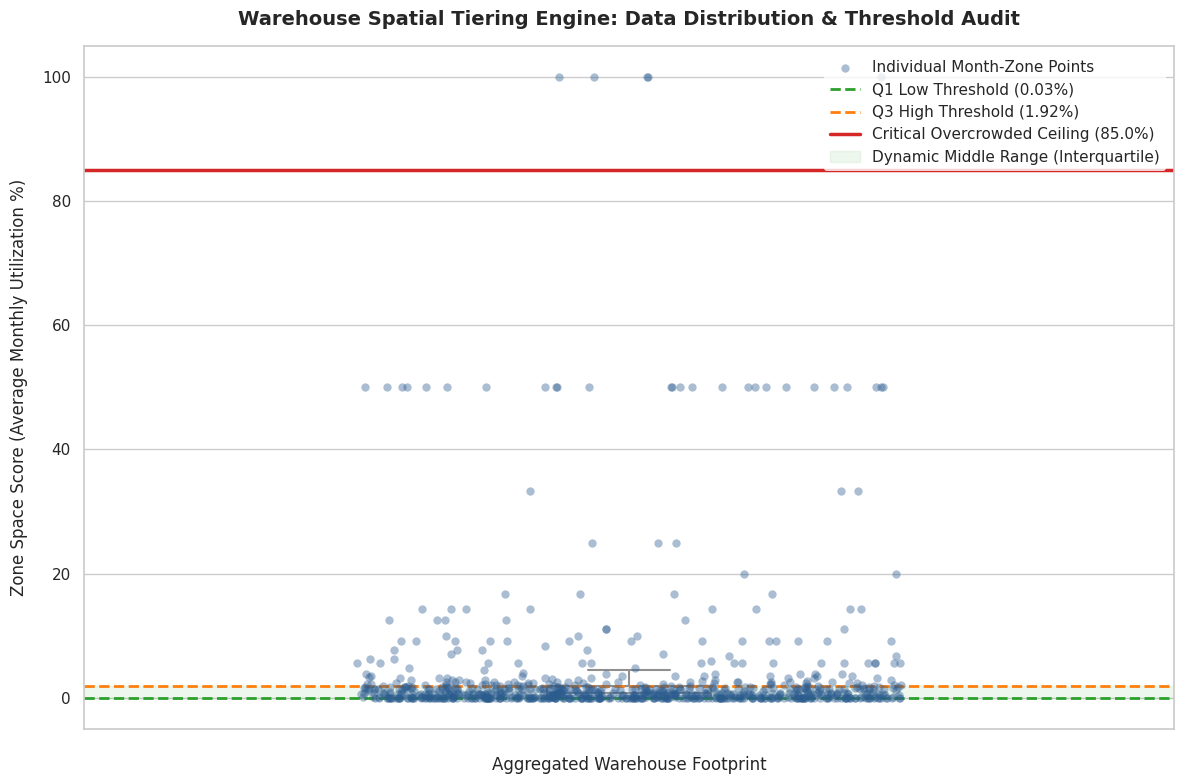

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set clean, professional plotting style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# 🚨 THE FIX: Use 'zone_month_space' (~750 true points) instead of 'item_space_df' (300k+ broadcasted points)
plot_df = zone_month_space 

# 1. Plot all individual data points with slight horizontal jitter so they don't pile up
sns.stripplot(
    data=plot_df, 
    y='Item_Space_Score', 
    color='#2b5c8f', 
    alpha=0.4, 
    size=6, 
    jitter=0.25,
    label='Individual Month-Zone Points'
)

# 2. Add an underlying subtle boxplot to show the mathematical distribution shape
sns.boxplot(
    data=plot_df, 
    y='Item_Space_Score', 
    color='#e6f0fa', 
    width=0.15, 
    fliersize=0, 
    linewidth=1.5
)

# 3. Draw the exact Data-Driven Threshold Lines
plt.axhline(y=q1, color='#2ca02c', linestyle='--', linewidth=2, 
            label=f'Q1 Low Threshold ({q1:.2f}%)')

plt.axhline(y=q3, color='#ff7f0e', linestyle='--', linewidth=2, 
            label=f'Q3 High Threshold ({q3:.2f}%)')

# 4. Draw the Fixed Corporate Physical Constraint Line mandated by your Head
plt.axhline(y=85.0, color='#d62728', linestyle='-', linewidth=2.5, 
            label='Critical Overcrowded Ceiling (85.0%)')

# 5. Shading the "Moderate Activity / Ideal Allocation Zone" (Between Q1 and Q3)
plt.axhspan(q1, q3, color='#2ca02c', alpha=0.08, 
            label='Dynamic Middle Range (Interquartile)')

# 6. Formatting Labels, Titles, and Legend for your Presentation
plt.title('Warehouse Spatial Tiering Engine: Data Distribution & Threshold Audit', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Zone Space Score (Average Monthly Utilization %)', fontsize=12, labelpad=10)
plt.xlabel('Aggregated Warehouse Footprint', fontsize=12, labelpad=10)
plt.ylim(-5, 105) # Keeps the percentage scale strictly operational from 0-100%

# Clean up duplicate legend labels caused by mixing seaborn plots
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

5. Machine Utilization

In [13]:
# =====================================================================
# PARAMETER 5: ITEM EQUIPMENT UTILIZATION SCORE (Item-Zone-Month)
# Stays true to original formula:
#   Equipment Score = (Active Equipment Time / Total Shift Hours) × 100
#   Cross-check: Picks per Equipment Hour = Total Picks / Equipment Hours
# Zone Score = median of Relative Equipment Efficiency across machines
# =====================================================================

import pandas as pd
import numpy as np

print("--- Parameter 5: Item Equipment Utilization Score Engine (Item-Zone-Month) ---")


# =====================================================================
# PRE-PROCESSING: Clean equipment IDs — identical to original
# =====================================================================
table1['storageSectionId'] = table1['storageSectionId'].astype(str).str.upper()
table1['pickHeNo']         = table1['pickHeNo'].astype(str).str.strip().str.upper()

if not np.issubdtype(table1['pickDate'].dtype, np.datetime64):
    table1['pickDate'] = pd.to_datetime(table1['pickDate'])
table1['pickMonth'] = table1['pickDate'].dt.to_period('M').astype(str)


# =====================================================================
# STEP 1: AGGREGATE TO MONTH-ZONE-EQUIPMENT LAYER
# Identical to original
# =====================================================================
equip_metrics_df = table1.groupby(
    ['pickMonth', 'storageSectionId', 'pickHeNo']
).agg(
    total_picked_units=('pickQty', 'sum'),
    active_time_seconds=('totalTimeSeconds', 'sum')
).reset_index()


# =====================================================================
# STEP 2: TIME UTILIZATION FORMULA — identical to original
# Equipment Score = (Active Equipment Time / 260 Total Shift Hours) × 100
# =====================================================================
equip_metrics_df['active_equip_hours'] = equip_metrics_df['active_time_seconds'] / 3600.0

equip_metrics_df['Time_Utilization_Score'] = (
    equip_metrics_df['active_equip_hours'] / 260.0
) * 100
equip_metrics_df['Time_Utilization_Score'] = equip_metrics_df['Time_Utilization_Score'].clip(upper=100.0)


# =====================================================================
# STEP 3: MACHINE BASELINES & RELATIVE EFFICIENCY — identical to original
# Cross-check: Picks per Equipment Hour = Total Picks / Equipment Hours
# =====================================================================
equip_metrics_df['Picks_per_Equipment_Hour'] = (
    equip_metrics_df['total_picked_units'] /
    (equip_metrics_df['active_equip_hours'] + 0.0001)
)

print("--> Calculating Baseline Speeds for each Specific Machine...")
global_baselines = equip_metrics_df.groupby('pickHeNo')['Picks_per_Equipment_Hour'].median().reset_index()
global_baselines.rename(columns={'Picks_per_Equipment_Hour': 'Specific_Machine_Baseline'}, inplace=True)

equip_metrics_df = pd.merge(equip_metrics_df, global_baselines, on='pickHeNo', how='left')

equip_metrics_df['Relative_Equipment_Efficiency'] = (
    equip_metrics_df['Picks_per_Equipment_Hour'] /
    (equip_metrics_df['Specific_Machine_Baseline'] + 0.0001)
) * 100
equip_metrics_df['Relative_Equipment_Efficiency'] = equip_metrics_df['Relative_Equipment_Efficiency'].clip(upper=100.0)


# =====================================================================
# STEP 4: ITEM-MACHINE-ZONE-MONTH BASE GRAIN
# New addition — track which items each machine handled
# =====================================================================
item_equip_df = table1.groupby(
    ['itemCode', 'pickHeNo', 'pickMonth', 'storageSectionId']
).agg(
    item_pick_volume=('pickQty', 'sum')
).reset_index()

# Bring in each machine's Time_Utilization_Score and Relative_Equipment_Efficiency
item_equip_df = item_equip_df.merge(
    equip_metrics_df[[
        'pickHeNo', 'pickMonth', 'storageSectionId',
        'Time_Utilization_Score', 'Relative_Equipment_Efficiency'
    ]],
    on=['pickHeNo', 'pickMonth', 'storageSectionId'],
    how='left'
)
item_equip_df['Time_Utilization_Score']      = item_equip_df['Time_Utilization_Score'].fillna(0)
item_equip_df['Relative_Equipment_Efficiency'] = item_equip_df['Relative_Equipment_Efficiency'].fillna(0)

item_equip_df['weighted_time_score']  = item_equip_df['Time_Utilization_Score']      * item_equip_df['item_pick_volume']
item_equip_df['weighted_equip_score'] = item_equip_df['Relative_Equipment_Efficiency'] * item_equip_df['item_pick_volume']


# =====================================================================
# STEP 5: COLLAPSE TO ITEM-ZONE-MONTH (vectorised)
# Volume-weighted average across all machines that touched this item
# Preserves both Time_Utilization_Score and Relative_Equipment_Efficiency
# at item level — mirrors the zone-level dual output from original
# =====================================================================
item_equip_scores_df = item_equip_df.groupby(
    ['itemCode', 'pickMonth', 'storageSectionId']
).agg(
    sum_weighted_time =('weighted_time_score',  'sum'),
    sum_weighted_equip=('weighted_equip_score', 'sum'),
    sum_volume        =('item_pick_volume',      'sum'),
    n_machines        =('pickHeNo',              'nunique')
).reset_index()

item_equip_scores_df['Item_Time_Utilization_Score'] = (
    item_equip_scores_df['sum_weighted_time'] /
    (item_equip_scores_df['sum_volume'] + 1e-9)
).clip(upper=100.0)

item_equip_scores_df['Item_Equipment_Score'] = (
    item_equip_scores_df['sum_weighted_equip'] /
    (item_equip_scores_df['sum_volume'] + 1e-9)
).clip(upper=100.0)


# =====================================================================
# STEP 6: ZONE-LEVEL AUDIT OUTPUT (original format preserved)
# =====================================================================
zone_equipment_summary = equip_metrics_df.groupby(
    ['pickMonth', 'storageSectionId']
).agg(
    Zone_Time_Utilization_Score=('Time_Utilization_Score',      'mean'),
    Zone_Equipment_Score       =('Relative_Equipment_Efficiency','median')
).reset_index()
zone_equipment_summary['Zone_Equipment_Score'] = zone_equipment_summary['Zone_Equipment_Score'].clip(upper=100.0)

print("\n--- Final Consolidated Equipment Matrix — Zone Level (First 20 Rows) ---")
zone_cols = ['pickMonth', 'storageSectionId', 'Zone_Time_Utilization_Score', 'Zone_Equipment_Score']
print(zone_equipment_summary[zone_cols].head(20).to_string(index=False))

print("\n--- Item Equipment Score Sample (First 20 Rows) ---")
item_cols = ['itemCode', 'pickMonth', 'storageSectionId',
             'n_machines', 'Item_Time_Utilization_Score', 'Item_Equipment_Score']
print(item_equip_scores_df[item_cols].head(20).to_string(index=False))

print("\n" + "="*65)
print("PARAMETER 5 AUDIT: EQUIPMENT PERFORMANCE SUMMARY")
print("="*65)
print(f"Total Month-Zone configurations analyzed        : {len(zone_equipment_summary)} rows")
print(f"Total Item-Zone-Month rows                      : {len(item_equip_scores_df)}")
print(f"Unique Individual Machines Tracked              : {table1['pickHeNo'].nunique()}")
print(f"Warehouse-wide avg machine TIME utilization     : {zone_equipment_summary['Zone_Time_Utilization_Score'].mean():.2f}%")
print(f"Warehouse-wide avg machine RELATIVE efficiency  : {zone_equipment_summary['Zone_Equipment_Score'].mean():.2f}%")
print(f"Item-level avg TIME utilization score           : {item_equip_scores_df['Item_Time_Utilization_Score'].mean():.2f}%")
print(f"Item-level avg EQUIPMENT score                  : {item_equip_scores_df['Item_Equipment_Score'].mean():.2f}%")

--- Parameter 5: Item Equipment Utilization Score Engine (Item-Zone-Month) ---
--> Calculating Baseline Speeds for each Specific Machine...

--- Final Consolidated Equipment Matrix — Zone Level (First 20 Rows) ---
pickMonth storageSectionId  Zone_Time_Utilization_Score  Zone_Equipment_Score
  2024-03               AA                     1.311293             98.673668
  2024-03               AB                     0.838251             74.911402
  2024-03               AC                     1.023874             75.508577
  2024-03               AD                     0.659509             62.394876
  2024-03               AE                     1.670358             62.004471
  2024-03               AF                     1.429781             62.814594
  2024-03               AG                     1.204048             65.660965
  2024-03               AH                     1.025977             72.092619
  2024-03               AI                     0.327869            100.000000
  2024

6. Putaway Location Accuracy

In [14]:
print("--- Engineering Parameter 6: Item Putaway Location Accuracy (Item-Zone-Month) ---")

# =====================================================================
# 1. STRING CLEANING FOR THE BINS
# =====================================================================
table3['storageBin'] = table3['storageBin'].astype(str).str.upper().str.strip()
table3['proposed_st_bin'] = table3['proposed_st_bin'].astype(str).str.upper().str.strip()

# =====================================================================
# 2. ROW-LEVEL ACCURACY CHECK
# =====================================================================
table3['is_bin_accurate'] = (table3['storageBin'] == table3['proposed_st_bin']).astype(int)

# =====================================================================
# 3. ITEM-ZONE-MONTH AGGREGATION
# Only change from original: added 'itemCode' to the groupby
# =====================================================================
putaway_accuracy_df = table3.groupby(['itemCode', 'putawayMonth', 'storageSectionId']).agg(
    total_putaways=('summary_id', 'size'),
    accurate_putaways=('is_bin_accurate', 'sum')
).reset_index()

putaway_accuracy_df['Item_Putaway_Accuracy_Score'] = (
    putaway_accuracy_df['accurate_putaways'] / putaway_accuracy_df['total_putaways']
) * 100

# =====================================================================
# 4. DATA VERIFICATION OUTPUT
# =====================================================================
print("\n--- Item Putaway Location Accuracy Preview (First 20 Rows) ---")
view_cols = ['itemCode', 'putawayMonth', 'storageSectionId',
             'total_putaways', 'Item_Putaway_Accuracy_Score']
print(putaway_accuracy_df[view_cols].head(20).to_string(index=False))

print("\n" + "="*60)
print("PARAM 6 STATISTICAL PROFILE")
print("="*60)
print(f"Total Item-Zone-Month rows          : {len(putaway_accuracy_df)}")
print(f"Global Avg Putaway Accuracy         : {putaway_accuracy_df['Item_Putaway_Accuracy_Score'].mean():.2f}%")
print(f"Worst Performing Item Score         : {putaway_accuracy_df['Item_Putaway_Accuracy_Score'].min():.2f}%")
print(f"Best Performing Item Score          : {putaway_accuracy_df['Item_Putaway_Accuracy_Score'].max():.2f}%")
print("-" * 60)

--- Engineering Parameter 6: Item Putaway Location Accuracy (Item-Zone-Month) ---

--- Item Putaway Location Accuracy Preview (First 20 Rows) ---
   itemCode putawayMonth storageSectionId  total_putaways  Item_Putaway_Accuracy_Score
 0155304753      2024-04               AA               1                          0.0
 0155304753      2024-06               AA               1                          0.0
 0155305933      2024-09               BB               1                        100.0
 0155305933      2025-04               BB               1                        100.0
 0155309611      2024-09               BB               1                        100.0
 015532DR9A      2025-07              LOC               1                          0.0
 015532DR9A      2025-09               BH               1                          0.0
 0211704523      2024-08               AD               1                          0.0
 0211704523      2025-02               AD               1              

7. Dock to Stock Time (Getting Large Values)

In [15]:
# =====================================================================
# PARAMETER 7: ITEM DOCK-TO-STOCK PERFORMANCE SCORE (Item-Zone-Month)
# =====================================================================
print("--- Engineering Parameter 7: Item Dock-to-Stock Score (Item-Zone-Month) ---")

# =====================================================================
# 1. NUMERATOR PREPARATION
# Weight each transaction by how many units were moved
# =====================================================================
table3['time_qty_product'] = table3['totalTimeinSeconds'] * table3['putAwayQty']

# =====================================================================
# 2. ITEM-ZONE-MONTH AGGREGATION
# Only change from original: added 'itemCode' to the groupby
# =====================================================================
d2s_item = table3.groupby(['itemCode', 'putawayMonth', 'storageSectionId']).agg(
    sum_time_qty_product=('time_qty_product', 'sum'),
    total_putaway_volume=('putAwayQty', 'sum'),
    total_transactions=('summary_id', 'count')
).reset_index()

# =====================================================================
# 3. WEIGHTED LEAD TIME FORMULA
# Result: Average seconds spent per unit putaway for this item this month
# Lower = faster = better
# =====================================================================
d2s_item['weighted_d2s_seconds'] = (
    d2s_item['sum_time_qty_product'] / (d2s_item['total_putaway_volume'] + 1e-5)
)

d2s_baseline_seconds = d2s_item['weighted_d2s_seconds'].median()

# =====================================================================
# 4. RANK-INVERT SCORING WITHIN EACH MONTH
# Ranking now across all item-zone combos in that month
# Fastest item = 100, slowest item = ~0
# =====================================================================
d2s_item['monthly_time_rank'] = d2s_item.groupby('putawayMonth')['weighted_d2s_seconds'].rank(pct=True)
d2s_item['Item_D2S_Score'] = (1.0 - d2s_item['monthly_time_rank']) * 100.0

putaway_d2s_df = d2s_item[['itemCode', 'putawayMonth', 'storageSectionId', 'Item_D2S_Score']].copy()

# =====================================================================
# 5. VERIFICATION OUTPUT
# =====================================================================
print("\n--- Item Dock-to-Stock Score Preview (First 20 Rows) ---")
view_cols = ['itemCode', 'putawayMonth', 'storageSectionId',
             'weighted_d2s_seconds', 'Item_D2S_Score']
print(d2s_item[view_cols].head(20).to_string(index=False))

print("\n" + "="*60)
print("DOCK-TO-STOCK STATISTICAL PROFILE")
print("="*60)
print(f"Total Item-Zone-Month records       : {len(d2s_item)}")
print(f"Global Avg D2S Score                : {d2s_item['Item_D2S_Score'].mean():.2f}")
print(f"Fastest Item Score (Max)            : {d2s_item['Item_D2S_Score'].max():.2f}")
print(f"Slowest Item Score (Min)            : {d2s_item['Item_D2S_Score'].min():.2f}")
print(f"Avg Weighted Lead Time              : {d2s_item['weighted_d2s_seconds'].mean():.0f} seconds")
print(f"Frozen d2s_baseline_seconds         : {d2s_baseline_seconds:.2f} seconds")
print("-"*60)

--- Engineering Parameter 7: Item Dock-to-Stock Score (Item-Zone-Month) ---

--- Item Dock-to-Stock Score Preview (First 20 Rows) ---
   itemCode putawayMonth storageSectionId  weighted_d2s_seconds  Item_D2S_Score
 0155304753      2024-04               AA            432.999869       47.023361
 0155304753      2024-06               AA            301.999497       67.626800
 0155305933      2024-09               BB           1840.999080       45.500849
 0155305933      2025-04               BB           3307.998346        5.834684
 0155309611      2024-09               BB           1606.998393       49.660441
 015532DR9A      2025-07              LOC            508.999491       63.457207
 015532DR9A      2025-09               BH            920.999079       60.704356
 0211704523      2024-08               AD           1576.984230       51.791277
 0211704523      2025-02               AD           3263.967360        5.381818
 0211707023      2025-04              LOC            420.995790   

8. Putaway Throughput

In [16]:
print("--- Engineering Parameter 8: Item Putaway Throughput Score (Item-Zone-Month) ---")

# =====================================================================
# 1. ITEM-ZONE-MONTH AGGREGATION
# Only change from original: added 'itemCode' to the groupby
# =====================================================================
throughput_summary = table3.groupby(['itemCode', 'putawayMonth', 'storageSectionId']).agg(
    total_putaway_qty=('putAwayQty', 'sum'),
    total_time_seconds=('totalTimeinSeconds', 'sum')
).reset_index()

# =====================================================================
# 2. THE CHIEF'S LINEAR FORMULA: Σ(qty) ÷ Σ(time)
# =====================================================================
throughput_summary['raw_throughput_rate'] = (
    throughput_summary['total_putaway_qty'] / (throughput_summary['total_time_seconds'] + 1e-5)
)

# =====================================================================
# 3. ROBUST SCALING LAYER — 75th-Percentile Ceiling Per Month
# Using 75th pct instead of max — same logic as original
# Ceiling computed across all item rows so benchmark stays warehouse-wide
# =====================================================================
monthly_throughput_ceilings = (
    throughput_summary.groupby('putawayMonth')['raw_throughput_rate']
    .quantile(0.75)
    .reset_index()
    .rename(columns={'raw_throughput_rate': 'throughput_ceiling'})
)

putaway_75th_ceiling_global = monthly_throughput_ceilings['throughput_ceiling'].median()

throughput_summary = throughput_summary.merge(
    monthly_throughput_ceilings, on='putawayMonth', how='left'
)

throughput_summary['Item_Putaway_Throughput_Score'] = (
    throughput_summary['raw_throughput_rate'] /
    (throughput_summary['throughput_ceiling'] + 1e-5)
) * 100

throughput_summary['Item_Putaway_Throughput_Score'] = (
    throughput_summary['Item_Putaway_Throughput_Score'].clip(lower=0.0, upper=100.0)
)

item_putaway_throughput_df = throughput_summary[
    ['itemCode', 'putawayMonth', 'storageSectionId', 'Item_Putaway_Throughput_Score']
].copy()

# =====================================================================
# 4. OUTPUT PREVIEW FOR DIAGNOSIS
# =====================================================================
print(f"\nFrozen putaway_75th_ceiling_global: {putaway_75th_ceiling_global:.6f}")

print("\n--- Item Putaway Throughput Score Preview (First 20 Rows) ---")
view_cols = ['itemCode', 'putawayMonth', 'storageSectionId',
             'total_putaway_qty', 'total_time_seconds',
             'raw_throughput_rate', 'Item_Putaway_Throughput_Score']
print(throughput_summary[view_cols].head(20).to_string(index=False))

print("\n" + "="*60)
print("PARAMETER 8 AUDIT: ITEM PUTAWAY THROUGHPUT SCORE")
print("="*60)
print(f"Total Item-Zone-Month rows          : {len(item_putaway_throughput_df)}")
print(f"Score mean                          : {item_putaway_throughput_df['Item_Putaway_Throughput_Score'].mean():.2f}")
print(f"Score median                        : {item_putaway_throughput_df['Item_Putaway_Throughput_Score'].median():.2f}")
print(f"Best item score  (max)              : {item_putaway_throughput_df['Item_Putaway_Throughput_Score'].max():.2f}")
print(f"Worst item score (min)              : {item_putaway_throughput_df['Item_Putaway_Throughput_Score'].min():.2f}")

--- Engineering Parameter 8: Item Putaway Throughput Score (Item-Zone-Month) ---

Frozen putaway_75th_ceiling_global: 0.013007

--- Item Putaway Throughput Score Preview (First 20 Rows) ---
   itemCode putawayMonth storageSectionId  total_putaway_qty  total_time_seconds  raw_throughput_rate  Item_Putaway_Throughput_Score
 0155304753      2024-04               AA               33.0               433.0             0.076212                     100.000000
 0155304753      2024-06               AA                6.0               302.0             0.019868                     100.000000
 0155305933      2024-09               BB               20.0              1841.0             0.010864                     100.000000
 0155305933      2025-04               BB               20.0              3308.0             0.006046                      40.480741
 0155309611      2024-09               BB               10.0              1607.0             0.006223                      94.054697
 015532DR9A 

Combining all 8 parameters

In [17]:
# =====================================================================
# CELL 1: MASTER JOIN - ITEM-ZONE-MONTH SCORED TABLE (8 PARAMETERS)
# =====================================================================
print("--- Master Join: Building Item-Zone-Month Scored Table (8 Parameters) ---")

# 1. Enforce string type on all month columns for safe merging
item_pick_rate_df['month'] = item_pick_rate_df['pickMonth'].astype(str)
item_throughput_df['month'] = item_throughput_df['pickMonth'].astype(str)
item_picker_scores_df['month'] = item_picker_scores_df['pickMonth'].astype(str)
item_equip_scores_df['month'] = item_equip_scores_df['pickMonth'].astype(str)

putaway_accuracy_df['month'] = putaway_accuracy_df['putawayMonth'].astype(str)
putaway_d2s_df['month'] = putaway_d2s_df['putawayMonth'].astype(str)
item_putaway_throughput_df['month'] = item_putaway_throughput_df['putawayMonth'].astype(str)

item_space_df['month'] = item_space_df['month'].astype(str)

# 2. Isolate the target columns for the join
p1 = item_pick_rate_df[['itemCode', 'month', 'storageSectionId', 'Item_Pick_Rate_Score']]
p2 = item_throughput_df[['itemCode', 'month', 'storageSectionId', 'Item_Throughput_Score']]
p3 = item_picker_scores_df[['itemCode', 'month', 'storageSectionId', 'Item_Picker_Performance_Score']]
p4 = item_space_df[['itemCode', 'month', 'storageSectionId', 'Item_Space_Score']]
p5 = item_equip_scores_df[['itemCode', 'month', 'storageSectionId', 'Item_Equipment_Score']]
p6 = putaway_accuracy_df[['itemCode', 'month', 'storageSectionId', 'Item_Putaway_Accuracy_Score']]
p7 = putaway_d2s_df[['itemCode', 'month', 'storageSectionId', 'Item_D2S_Score']]
p8 = item_putaway_throughput_df[['itemCode', 'month', 'storageSectionId', 'Item_Putaway_Throughput_Score']]

KEYS = ['itemCode', 'month', 'storageSectionId']
dfs = [p1, p2, p3, p4, p5, p6, p7, p8]

# 3. Create the definitive union of all keys
master_keys = pd.concat([df[KEYS] for df in dfs]).drop_duplicates().reset_index(drop=True)
print(f"Union key rows (total unique item-zone-month combos): {len(master_keys)}")

# 4. Left join each parameter in a loop
master = master_keys.copy()
for i, df in enumerate(dfs, 1):
    master = master.merge(df, on=KEYS, how='left')
    print(f"  After P{i}: {master.shape}")

features_to_process = [
    'Item_Pick_Rate_Score', 'Item_Throughput_Score',
    'Item_Picker_Performance_Score', 'Item_Space_Score',
    'Item_Equipment_Score', 'Item_Putaway_Throughput_Score',
    'Item_D2S_Score', 'Item_Putaway_Accuracy_Score'
]

# 5. Two-step Vectorised Imputation & Clipping
print("\n--- Running Two-Step Imputation ---")
for col in features_to_process:
    # Step 1: Item's own zone median
    master[col] = master[col].fillna(master.groupby(['itemCode', 'storageSectionId'])[col].transform('median'))
    # Step 2: Warehouse-wide column median backstop
    master[col] = master[col].fillna(master[col].median())
    # Step 3: Absolute value bounds
    master[col] = master[col].clip(lower=0.0, upper=100.0)

print(f"\nFinal Master shape: {master.shape}")
print(f"Nulls remaining: {master[features_to_process].isnull().sum().sum()}")

# --- ADD THIS TO THE BOTTOM OF CELL 1 TO CHECK YOUR OUTPUT ---

print("\n--- Final Master Table Preview (First 20 Rows) ---")
# Using .to_string() forces Jupyter to print all columns without truncating them
print(master.head(20).to_string(index=False))

print("\n--- Master Table Information ---")
# This will confirm all 11 columns are present and perfectly non-null
master.info()
print("============================================================")

--- Master Join: Building Item-Zone-Month Scored Table (8 Parameters) ---
Union key rows (total unique item-zone-month combos): 310536
  After P1: (310536, 4)
  After P2: (310536, 5)
  After P3: (310536, 6)
  After P4: (310536, 7)
  After P5: (310536, 8)
  After P6: (310536, 9)
  After P7: (310536, 10)
  After P8: (310536, 11)

--- Running Two-Step Imputation ---

Final Master shape: (310536, 11)
Nulls remaining: 0

--- Final Master Table Preview (First 20 Rows) ---
   itemCode   month storageSectionId  Item_Pick_Rate_Score  Item_Throughput_Score  Item_Picker_Performance_Score  Item_Space_Score  Item_Equipment_Score  Item_Putaway_Accuracy_Score  Item_D2S_Score  Item_Putaway_Throughput_Score
01463SE0911 2024-12               AA             99.999774              49.363595                      56.322353              0.02            100.000000                    83.333333       37.905774                      10.715767
 0155305131 2024-11               AA             99.999739             

Comparison of models

In [18]:
# import matplotlib.pyplot as plt

# # =====================================================================
# # 1. WEIGHTED LINEAR MATH MODEL (Apples-to-Apples Baseline)
# # =====================================================================
# scaler_linear = MinMaxScaler(feature_range=(0, 100))
# linear_scaled = scaler_linear.fit_transform(master_zone_df[features_to_cluster])

# # THE FIX: Replace .mean() with np.dot() to apply the exact same business percentages
# master_zone_df['Linear_Score'] = np.dot(linear_scaled, business_weights)

# # =====================================================================
# # 2. UNGATED WEIGHTED K-MEANS (Testing the ML without Safety Gates)
# # =====================================================================
# ungated_scores = []

# # THE FIX: Added enumerate and enum_i
# for enum_i, (i, row) in enumerate(master_zone_df.iterrows()):
#     assigned_cluster = row['Zone_Cluster_Label']
    
#     # THE FIX: Safely pull from distances using enum_i
#     d1 = distances[enum_i, tier1_idx]
#     d2 = distances[enum_i, tier2_idx]
#     d3 = distances[enum_i, tier3_idx]
    
#     if assigned_cluster == tier3_idx:
#         score = 33.33 * (1 - (d3 / (d3 + d2 + 1e-5)))
#     elif assigned_cluster == tier2_idx:
#         if d3 < d1:
#             score = 33.33 + (16.67 * (d3 / (d2 + d3 + 1e-5)))
#         else:
#             score = 50.00 + (16.66 * (1 - (d2 / (d1 + d2 + 1e-5))))
#     else:
#         score = 66.66 + (33.34 * (d2 / (d1 + d2 + 1e-5)))
#     ungated_scores.append(score)
    
# master_zone_df['Ungated_KMeans_Score'] = ungated_scores

# # =====================================================================
# # 3. BUILD ZOMBIE ZONE & APPLY BUSINESS WEIGHTS
# # =====================================================================
# # Ensure this dictionary exactly matches your 5 surviving parameters
# zombie_features = {
#     # The Core Failures (Outbound and Inbound are dead on a 0-100 scale)
#     'Zone_Pick_Rate_Score': 2.0,            
#     'Zone_Throughput_Score': 2.0,           
#     'Putaway_Throughput_Score': 4.0,        
#     'Dock_to_Stock_Score': 4.0,             
    
#     # The "Trap" Metrics (Artificially High, properly scaled)
#     'Space_Score': 4.9,                     # Max physical space score is ~5.0
#     'Zone_Equipment_Score': 3.0,            # Max physical equipment score is ~3.0
#     'Putaway_Location_Accuracy_Score': 99.0,# 0-100 scale
#     'Zone_Picker_Performance_Score': 85.0   # 0-100 scale
# }

# # Convert to DataFrame
# zombie_df = pd.DataFrame([zombie_features])

# # Score zombie through WEIGHTED LINEAR MODEL
# # This will now work perfectly because all 8 columns match features_to_cluster!
# zombie_linear_scaled = scaler_linear.transform(zombie_df[features_to_cluster])
# zombie_linear_score = np.dot(zombie_linear_scaled, business_weights)[0]

# # Score zombie through UNGATED WEIGHTED K-MEANS
# # THE FIX: Use the new business variables!
# zombie_scaled_strict = scaler_business.transform(zombie_df[features_to_cluster])
# zombie_weighted = zombie_scaled_strict * np.sqrt(business_weights)

# zombie_cluster = kmeans.predict(zombie_weighted)[0]
# zombie_distances = kmeans.transform(zombie_weighted)[0]

# zd1, zd2, zd3 = zombie_distances[tier1_idx], zombie_distances[tier2_idx], zombie_distances[tier3_idx]

# if zombie_cluster == tier3_idx:
#     zombie_ungated = 33.33 * (1 - (zd3 / (zd3 + zd2 + 1e-5)))
# elif zombie_cluster == tier2_idx:
#     if zd3 < zd1:
#         zombie_ungated = 33.33 + (16.67 * (zd3 / (zd2 + zd3 + 1e-5)))
#     else:
#         zombie_ungated = 50.00 + (16.66 * (1 - (zd2 / (zd1 + zd2 + 1e-5))))
# else:
#     zombie_ungated = 66.66 + (33.34 * (zd2 / (zd1 + zd2 + 1e-5)))

# # Score zombie through HYBRID MODEL
# zombie_hybrid = 0.0  # Gate fires naturally

# # =====================================================================
# # 4. SELECT REAL ZONES FOR CHART
# # =====================================================================
# best_zone = master_zone_df.loc[master_zone_df['Zone_Efficiency_Score'].idxmax()].copy()
# tier2_zones = master_zone_df[master_zone_df['Zone_Efficiency_Tier'] == 'Tier 2: Moderate Efficiency']
# avg_zone = tier2_zones.iloc[len(tier2_zones) // 2].copy()
# worst_zone = master_zone_df.loc[master_zone_df['Zone_Efficiency_Score'].idxmin()].copy()

# plot_data = pd.DataFrame([
#     {
#         'Label': f"Real Best Zone\n({best_zone['storageSectionId']})",
#         'Linear_Score': best_zone['Linear_Score'],
#         'Ungated_KMeans_Score': best_zone['Ungated_KMeans_Score'],
#         'Hybrid_Score': best_zone['Zone_Efficiency_Score']
#     },
#     {
#         'Label': f"Real Average Zone\n({avg_zone['storageSectionId']})",
#         'Linear_Score': avg_zone['Linear_Score'],
#         'Ungated_KMeans_Score': avg_zone['Ungated_KMeans_Score'],
#         'Hybrid_Score': avg_zone['Zone_Efficiency_Score']
#     },
#     {
#         'Label': "Zombie Zone\n(Broken Aisle, System Test)",
#         'Linear_Score': zombie_linear_score,
#         'Ungated_KMeans_Score': zombie_ungated,
#         'Hybrid_Score': zombie_hybrid
#     },
#     {
#         'Label': f"Real Worst Zone\n({worst_zone['storageSectionId']})",
#         'Linear_Score': worst_zone['Linear_Score'],
#         'Ungated_KMeans_Score': worst_zone['Ungated_KMeans_Score'],
#         'Hybrid_Score': worst_zone['Zone_Efficiency_Score']
#     }
# ])

# # =====================================================================
# # 5. PLOT CHART
# # =====================================================================
# fig, ax = plt.subplots(figsize=(11, 6))
# x = np.arange(len(plot_data))
# width = 0.25

# rects1 = ax.bar(x - width, plot_data['Linear_Score'], width, label='Pure Linear Weighted Math Model', color='#A0A0A0')
# rects2 = ax.bar(x, plot_data['Ungated_KMeans_Score'], width, label='Ungated Weighted K-Means', color='#1F77B4')
# rects3 = ax.bar(x + width, plot_data['Hybrid_Score'], width, label='Our Entropy Hybrid (Deployed)', color='#2CA02C')

# ax.set_ylabel('Efficiency Score (0 - 100)', fontweight='bold', fontsize=12)
# ax.set_title('Real Warehouse Architecture Validation & Stress Test', fontweight='bold', fontsize=14, pad=15)
# ax.set_xticks(x)
# ax.set_xticklabels(plot_data['Label'], fontweight='bold', fontsize=10)
# ax.set_ylim(0, 115)
# ax.grid(axis='y', linestyle='--', alpha=0.5)
# ax.legend(loc='upper right', frameon=True, shadow=True)

# for rects in [rects1, rects2, rects3]:
#     for rect in rects:
#         height = rect.get_height()
#         ax.annotate(f'{height:.1f}',
#                     xy=(rect.get_x() + rect.get_width() / 2, height),
#                     xytext=(0, 3), textcoords='offset points',
#                     ha='center', va='bottom', fontsize=9, fontweight='bold')

# ax.annotate('CRITICAL FAILURE:\nLinear Math & Un-gated ML\ngive a passing score to a\nsimulated broken aisle!',
#             xy=(2, zombie_ungated), xytext=(2.65, 68),
#             arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=6),
#             ha='center', fontweight='bold', color='red',
#             bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='red', lw=1.5))

# plt.tight_layout()
# plt.show()

Group AHP Weights

In [19]:
# =====================================================================
# PHASE 1: GROUP AHP & CONSISTENCY EXTRACTION ENGINE
# =====================================================================
import pandas as pd
import numpy as np

print("--- Initializing Group AHP Strategy Engine ---")

def extract_ahp_matrix_from_excel(excel_path, sheet_name):
    # 1. Read the Excel sheet natively
    df = pd.read_excel(excel_path, sheet_name=sheet_name, engine='openpyxl')
    
    # 2. Extract the engineering parameter names from the correct row
    param_names = df.iloc[1, 2:10].values.tolist()
    
    # 3. Isolate the core 8x8 pairwise matrix grid
    matrix_grid = df.iloc[2:10, 2:10].copy()
    matrix_grid.index = param_names
    matrix_grid.columns = param_names
    
    # 4. Parser to convert text fractions ('1/3') or weird types safely to floats
    def parse_to_float(value):
        if pd.isna(value):
            return 1.0  # Default diagonal assignment
        val_str = str(value).strip()
        if '/' in val_str:
            num, denom = val_str.split('/')
            return float(num) / float(denom)
        return float(val_str)

    # 5. Version-proof element mapping
    if hasattr(matrix_grid, 'map'):
        cleaned_matrix = matrix_grid.map(parse_to_float)
    else:
        cleaned_matrix = matrix_grid.applymap(parse_to_float)
        
    return cleaned_matrix

# =====================================================================
# 1. RUN THE EXTRACTION FOR BOTH EXPERTS
# =====================================================================
excel_path = "/home/adityaa/Desktop/internship/Group AHP Scores.xlsx"

# Make sure the sheet_name matches exactly what is in your Excel file
matrix_1_df = extract_ahp_matrix_from_excel(excel_path, sheet_name="Matrix_1")
matrix_2_df = extract_ahp_matrix_from_excel(excel_path, sheet_name="Matrix_2") # Change this if the second sheet is named differently!

# Convert the DataFrames to pure mathematical Numpy arrays
head_matrix = matrix_1_df.values
senior_matrix = matrix_2_df.values

# Extract dynamic features and matrix size
ahp_features = matrix_1_df.columns.tolist()
n = len(ahp_features)

# =====================================================================
# 2. CALCULATE GROUP CONSENSUS (GEOMETRIC MEAN)
# =====================================================================
# Because there are 2 experts, we take the square root of their product.
consensus_matrix = np.sqrt(head_matrix * senior_matrix)

# =====================================================================
# 3. CALCULATE PRIORITY VECTOR (THE EXPERT WEIGHTS)
# =====================================================================
# Step A: Normalize the consensus matrix by dividing by column sums
col_sums = consensus_matrix.sum(axis=0)
normalized_matrix = consensus_matrix / col_sums

# Step B: Calculate the row averages to get the final weights
ahp_weights = normalized_matrix.mean(axis=1)

# =====================================================================
# 4. CONSISTENCY RATIO (CR) CHECK
# =====================================================================
# Standard Random Index (RI) values for n=1 to 10
RI_dict = {1:0.0, 2:0.0, 3:0.58, 4:0.90, 5:1.12, 6:1.24, 7:1.32, 8:1.41, 9:1.45, 10:1.49}

# Calculate Lambda Max
weighted_sum_vector = np.dot(consensus_matrix, ahp_weights)
lambda_max = (weighted_sum_vector / ahp_weights).mean()

# Calculate Consistency Index (CI) and Consistency Ratio (CR)
CI = (lambda_max - n) / (n - 1)
CR = CI / RI_dict[n]

# =====================================================================
# 5. OUTPUT & AUDIT REPORT
# =====================================================================
print("\n" + "="*50)
print("CORPORATE STRATEGY (AHP) WEIGHTS EXTRACTED")
print("="*50)

# Create a clean dataframe to display the weights
ahp_df = pd.DataFrame({
    'Operational Parameter': ahp_features,
    'Strategic Weight': ahp_weights * 100
})
ahp_df = ahp_df.sort_values(by='Strategic Weight', ascending=False).reset_index(drop=True)

for index, row in ahp_df.iterrows():
    print(f" {row['Strategic Weight']:05.2f}% | {row['Operational Parameter']}")

print("\n" + "-"*50)
print(" ⚖️  CONSISTENCY AUDIT (CR TEST)")
print("-" * 50)
print(f" Consistency Ratio (CR) : {CR:.4f}")

if CR < 0.10:
    print("PASS: The management strategy is highly consistent and logically sound.")
else:
    print(" ❌ FAIL: CR is above 0.10. The pairwise comparisons contain logical contradictions.")
    print("          (e.g., A > B, B > C, but C > A). Please review the matrix inputs.")
print("="*50 + "\n")

--- Initializing Group AHP Strategy Engine ---

CORPORATE STRATEGY (AHP) WEIGHTS EXTRACTED
 20.35% | Throughput Score
 18.78% | Putaway Accuracy
 18.77% | Putaway Throughput
 18.42% | Pick Rate Score
 09.86% | Space Score
 05.50% | Dock-to-Stock Score
 05.45% | Picker Performance
 02.87% | Equipment Score

--------------------------------------------------
 ⚖️  CONSISTENCY AUDIT (CR TEST)
--------------------------------------------------
 Consistency Ratio (CR) : 0.0356
PASS: The management strategy is highly consistent and logically sound.



CRITIC + GROUP AHP + HYBRID Weights

In [20]:
# =====================================================================
# CELL 2: CRITIC + AHP + HYBRID WEIGHTS AT ITEM LEVEL
# =====================================================================
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd

print("--- CRITIC + AHP + Hybrid Weights (Item-Zone-Month Level) ---")

features_to_process = [
    'Item_Pick_Rate_Score', 'Item_Throughput_Score',
    'Item_Picker_Performance_Score', 'Item_Space_Score',
    'Item_Equipment_Score', 'Item_Putaway_Throughput_Score',
    'Item_D2S_Score', 'Item_Putaway_Accuracy_Score'
]

# Standardize master target features for CRITIC variance detection
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(master[features_to_process])
scaled_df = pd.DataFrame(scaled_data, columns=features_to_process)

# 1. Calculate Pure CRITIC Weights based on Item-Level distributions
std_dev = scaled_df.std()
corr_matrix = scaled_df.corr().fillna(0)
conflict = (1 - corr_matrix).sum(axis=1)
information_quantity = std_dev * conflict
critic_weights = (information_quantity / information_quantity.sum()).values

print("\n--- PURE CRITIC WEIGHTS ---")
for col, w in zip(features_to_process, critic_weights):
    print(f"{col}: {w*100:.2f}%")

print("\n--- EXPERT AHP WEIGHTS ---")
for col, w in zip(features_to_process, ahp_weights):
    print(f"{col}: {w*100:.2f}%")

# 2. Multiplicative Synthesis (Hybrid weights)
# FIXED — additive (original method, alpha=0.5)
alpha = 0.5
hybrid_weights = (alpha * ahp_weights) + ((1 - alpha) * critic_weights)
# already sums to 1 since both weight arrays sum to 1, no renormalisation needed

print("\n--- HYBRID WEIGHTS (CRITIC * AHP) ---")
for col, w in zip(features_to_process, hybrid_weights):
    print(f"{col}: {w*100:.2f}%")

print("\n" + "="*60)
print("WEIGHTING AUDIT COMPLETE")
print("="*60)

--- CRITIC + AHP + Hybrid Weights (Item-Zone-Month Level) ---

--- PURE CRITIC WEIGHTS ---
Item_Pick_Rate_Score: 14.43%
Item_Throughput_Score: 12.93%
Item_Picker_Performance_Score: 12.85%
Item_Space_Score: 1.99%
Item_Equipment_Score: 8.54%
Item_Putaway_Throughput_Score: 15.23%
Item_D2S_Score: 10.28%
Item_Putaway_Accuracy_Score: 23.74%

--- EXPERT AHP WEIGHTS ---
Item_Pick_Rate_Score: 18.42%
Item_Throughput_Score: 20.35%
Item_Picker_Performance_Score: 5.45%
Item_Space_Score: 9.86%
Item_Equipment_Score: 2.87%
Item_Putaway_Throughput_Score: 18.77%
Item_D2S_Score: 5.50%
Item_Putaway_Accuracy_Score: 18.78%

--- HYBRID WEIGHTS (CRITIC * AHP) ---
Item_Pick_Rate_Score: 16.42%
Item_Throughput_Score: 16.64%
Item_Picker_Performance_Score: 9.15%
Item_Space_Score: 5.93%
Item_Equipment_Score: 5.71%
Item_Putaway_Throughput_Score: 17.00%
Item_D2S_Score: 7.89%
Item_Putaway_Accuracy_Score: 21.26%

WEIGHTING AUDIT COMPLETE


Finding 'k'

--- Revalidating k with Elbow Method on Item-Level Data ---
k=2 | Inertia: 12760.63
k=3 | Inertia: 10073.97
k=4 | Inertia: 8604.04
k=5 | Inertia: 7286.55
k=6 | Inertia: 6168.04
k=7 | Inertia: 5663.88
k=8 | Inertia: 5172.20
k=9 | Inertia: 4847.42
k=10 | Inertia: 4581.14


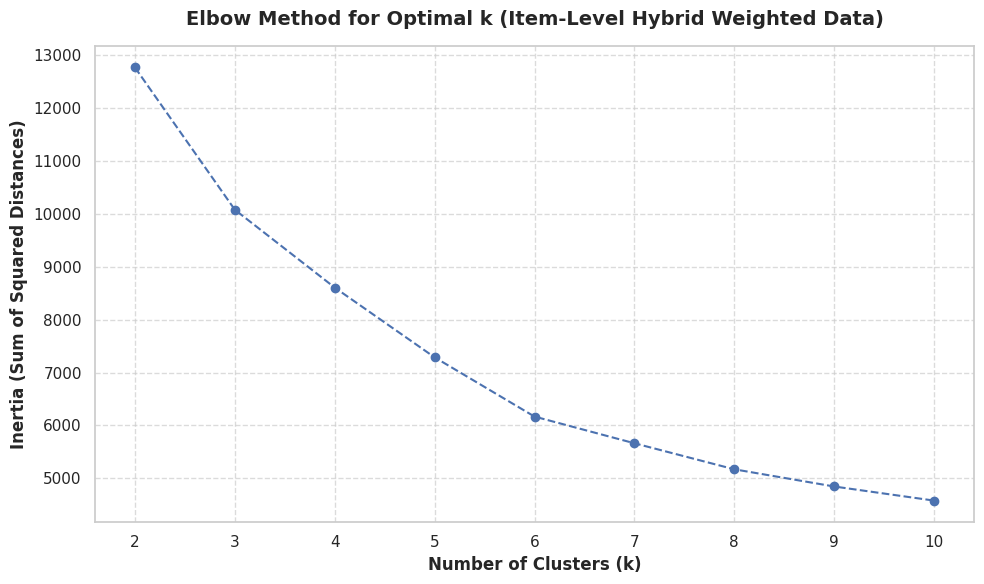

ELBOW METHOD AUDIT COMPLETE


In [21]:
# =====================================================================
# CELL 3: ELBOW METHOD ON ITEM-ZONE-MONTH SCALED DATA
# =====================================================================
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

print("--- Revalidating k with Elbow Method on Item-Level Data ---")

# Apply hybrid weights using Square Root Euclidean stretch to map the space correctly
X_hybrid_weighted = scaled_data * np.sqrt(hybrid_weights)

inertia_values = []
k_range = range(2, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans_temp.fit(X_hybrid_weighted)
    inertia_values.append(kmeans_temp.inertia_)
    print(f"k={k} | Inertia: {kmeans_temp.inertia_:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal k (Item-Level Hybrid Weighted Data)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
plt.ylabel('Inertia (Sum of Squared Distances)', fontsize=12, fontweight='bold')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("="*60)
print("ELBOW METHOD AUDIT COMPLETE")
print("="*60)

TOPSIS + K-MEANS

In [22]:
# =====================================================================
# CELL 4: MULTI-TRACK PIECEWISE SCORING ENGINE (ITEM LEVEL)
# =====================================================================
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

print("--- Generating Multi-Track Meticulous Efficiency Scores ---")

# Ensure old names align with Cell 2 outputs
data_track_weights = critic_weights
strategy_track_weights = ahp_weights
hybrid_track_weights = hybrid_weights

def calculate_piecewise_scores(weights, track_name):
    print(f"Processing {track_name} Track...")
    
    # 1. K-MEANS CLUSTERING (Internal use for geometric distances)
    X_kmeans = scaled_data * np.sqrt(weights)
    kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_kmeans)

    # Rank the clusters by their composite center scores
    cluster_composite_scores = kmeans.cluster_centers_.mean(axis=1)
    sorted_clusters = np.argsort(cluster_composite_scores)

    t1_idx = sorted_clusters[2] # High Efficiency Center
    t2_idx = sorted_clusters[1] # Moderate Efficiency Center
    t3_idx = sorted_clusters[0] # Low Efficiency Center

    # Get the geometric distances for the piecewise curve
    distances = kmeans.transform(X_kmeans)
    d1 = distances[:, t1_idx]
    d2 = distances[:, t2_idx]
    d3 = distances[:, t3_idx]

    # 2. VECTORISED PIECEWISE CURVE INTERPOLATION & TIER LABELS
    scores = np.zeros(len(master))
    tiers = np.empty(len(master), dtype=object)

    c_t3 = (cluster_labels == t3_idx)
    c_t2_lower = (cluster_labels == t2_idx) & (d3 < d1)
    c_t2_upper = (cluster_labels == t2_idx) & (d3 >= d1)
    c_t1 = (cluster_labels == t1_idx)

    # Assign Scores and Text Tiers
    scores[c_t3] = 33.33 * (1 - (d3[c_t3] / (d3[c_t3] + d2[c_t3] + 1e-5)))
    tiers[c_t3] = 'Tier 3 (Low Efficiency)'

    scores[c_t2_lower] = 33.33 + (16.67 * (d3[c_t2_lower] / (d2[c_t2_lower] + d3[c_t2_lower] + 1e-5)))
    tiers[c_t2_lower] = 'Tier 2 (Moderate Efficiency)'

    scores[c_t2_upper] = 50.00 + (16.66 * (1 - (d2[c_t2_upper] / (d1[c_t2_upper] + d2[c_t2_upper] + 1e-5))))
    tiers[c_t2_upper] = 'Tier 2 (Moderate Efficiency)'

    scores[c_t1] = 66.66 + (33.34 * (d2[c_t1] / (d1[c_t1] + d2[c_t1] + 1e-5)))
    tiers[c_t1] = 'Tier 1 (High Efficiency)'

    # 3. OPERATIONAL SAFETY GUARDRAILS
    pk_rate = master['Item_Pick_Rate_Score'].values
    ob_thru = master['Item_Throughput_Score'].values
    d2s = master['Item_D2S_Score'].values
    pa_thru = master['Item_Putaway_Throughput_Score'].values

    # Guardrail A: True Zombie Zone
    zombie_mask = (pk_rate <= 5.0) & (ob_thru <= 5.0) & (d2s <= 10.0) & (pa_thru <= 10.0)
    scores[zombie_mask] = 0.0
    tiers[zombie_mask] = 'Tier 3 (Low Efficiency)'

    # Guardrail B: Perfect World Zone
    perfect_mask = (pk_rate >= 82.0) & (ob_thru >= 89.0) & (d2s >= 85.0) & (pa_thru >= 85.0)
    scores[perfect_mask] = 100.0
    tiers[perfect_mask] = 'Tier 1 (High Efficiency)'

    # Return scores, tiers, and cluster metadata
    return scores, tiers, kmeans, int(t1_idx), int(t2_idx), int(t3_idx)

# Execute for all three tracks
master['Data_Efficiency_Score'], data_tiers, kmeans_data, t1_data, t2_data, t3_data = calculate_piecewise_scores(data_track_weights, "Data")
master['Strategy_Efficiency_Score'], strategy_tiers, kmeans_strategy, t1_strategy, t2_strategy, t3_strategy = calculate_piecewise_scores(strategy_track_weights, "Strategy")
master['Hybrid_Efficiency_Score'], hybrid_tiers, kmeans_hybrid, t1_hybrid, t2_hybrid, t3_hybrid = calculate_piecewise_scores(hybrid_track_weights, "Hybrid")

print("\n--- FINAL OUTPUT: MULTI-TRACK ITEM EFFICIENCY TABLE ---")

final_cols = [
    'month', 'storageSectionId', 'itemCode', 
    'Data_Efficiency_Score', 'Strategy_Efficiency_Score', 'Hybrid_Efficiency_Score'
]

final_df = master[final_cols].sort_values(['month', 'storageSectionId', 'itemCode']).reset_index(drop=True)

print("\n--- Final Master Table Preview (First 20 Rows) ---")
print(final_df.head(20).to_string(index=False))

print("\n" + "="*60)
print("FINAL WAREHOUSE ITEM-LEVEL EFFICIENCY AUDIT")
print("="*60)
print(f"Total Item-Zone-Month Rows : {len(final_df)}")
print(f"Unique Items Tracked       : {final_df['itemCode'].nunique()}")

print("\n--- Hybrid Score Distribution (0-100 Spread) ---")
print(final_df['Hybrid_Efficiency_Score'].describe().round(2).to_string())
print("="*60)

# =====================================================================
# MULTI-TRACK TIER DISTRIBUTIONS
# =====================================================================
def print_tier_distribution(tiers_array, track_name):
    print(f"\n--- {track_name} Tier Distribution ---")
    tier_counts = pd.Series(tiers_array).value_counts()
    tier_pct = (tier_counts / len(tiers_array) * 100).round(2)

    for tier_name, count in tier_counts.items():
        pct = tier_pct[tier_name]
        print(f"{tier_name:<30} : {count:,} rows ({pct}%)")

# Print for all 3 methods so you can compare them perfectly
print_tier_distribution(data_tiers, "CRITIC (Data-Driven)")
print_tier_distribution(strategy_tiers, "AHP (Expert Strategy)")
print_tier_distribution(hybrid_tiers, "Hybrid (Combined)")
print("="*60)

--- Generating Multi-Track Meticulous Efficiency Scores ---
Processing Data Track...
Processing Strategy Track...
Processing Hybrid Track...

--- FINAL OUTPUT: MULTI-TRACK ITEM EFFICIENCY TABLE ---

--- Final Master Table Preview (First 20 Rows) ---
  month storageSectionId    itemCode  Data_Efficiency_Score  Strategy_Efficiency_Score  Hybrid_Efficiency_Score
2024-03               AA 01463SE0911              87.853462                  92.951267                90.188287
2024-03               AA  0155305933              93.975353                  95.473213                93.975991
2024-03               AA  0155308231              93.975353                  95.473213                93.975991
2024-03               AA  0155309241              93.975353                  95.473213                93.975991
2024-03               AA  0155309611              93.975353                  95.473213                93.975991
2024-03               AA  015532DR9A              93.975353                  9

In [23]:
# =====================================================================
# CELL 6: MASTER ARCHITECTURE EXPORT LAYER (COMPREHENSIVE MATRIX)
# =====================================================================
import os
import pandas as pd

print("--- Preparing Comprehensive Multi-Track Export Layout (Item Level) ---")

# 1. Define the 8 specific engineered parameter columns (Updated for Item Level)
parameter_cols = [
    'Item_Pick_Rate_Score', 'Item_Throughput_Score',
    'Item_Picker_Performance_Score', 'Item_Space_Score',
    'Item_Equipment_Score', 'Item_Putaway_Throughput_Score',
    'Item_D2S_Score', 'Item_Putaway_Accuracy_Score'
]

try:
    # 2. Build the exact output column template with reader-friendly aliases
    export_df = pd.DataFrame()
    
    # Core Identifiers (Now includes itemCode)
    export_df['month'] = master['month']
    export_df['zone'] = master['storageSectionId']
    export_df['itemCode'] = master['itemCode']
    
    # The Three K-Means Curved Performance Scores (0-100 Scale)
    # NOTE: 'Tier' columns are intentionally omitted so the Frontend UI can control thresholds
    export_df['score_data'] = master['Data_Efficiency_Score'].round(2)
    export_df['score_expert'] = master['Strategy_Efficiency_Score'].round(2)
    export_df['score_hybrid'] = master['Hybrid_Efficiency_Score'].round(2)
    
    # 3. Dynamic Injection of the 8 Operational Parameters (Rounded for clean output)
    for col in parameter_cols:
        export_df[col] = master[col].round(2)
        
    # 4. Append the 8 Frozen Hybrid Weights as constant columns across all rows
    # hybrid_weights contains the raw decimals, multiplying by 100 turns them into percentages
    for col, weight_val in zip(parameter_cols, hybrid_weights):
        weight_col_name = f"Weight_{col}"
        export_df[weight_col_name] = round(weight_val * 100, 2)
        
    # 5. Execute Chronological Sorting (Month first, then Zone, then ItemCode)
    export_df = export_df.sort_values(by=['month', 'zone', 'itemCode']).reset_index(drop=True)
    
    # 6. Save natively to local workspace
    master_output_csv = "Warehouse_Item_Complete_Efficiency_Matrix.csv"
    export_df.to_csv(master_output_csv, index=False)
    
    print("=" * 75)
    print(" 🎉 SUCCESS: Expanded Master Data & Weights Matrix Saved Successfully!")
    print(f" -> Total Assessment Rows Saved : {len(export_df)} records")
    print(f" -> Total Data Attributes Locked: {len(export_df.columns)} columns")
    print(f" -> Generated Output Filename   : {master_output_csv}")
    print(f" -> Destination Directory Loc   : {os.getcwd()}")
    print("=" * 75)
    
    # Display columns and head preview to confirm structural compliance
    print("\n--- Structural Sheet Column Breakdown Preview ---")
    print(list(export_df.columns))
    print("\n--- Verified Dataset Preview (First 3 Rows) ---")
    print(export_df.head(3).to_string(index=False))

except NameError as e:
    print(f"\n ❌ VARIABLE ALIGNMENT ERROR: {str(e)}")
    print("    Please ensure you ran the previous Multi-Track cell to populate the master training variables.")
except Exception as e:
    print(f"\n ❌ EXPORT FAULT DETECTED: {str(e)}")

--- Preparing Comprehensive Multi-Track Export Layout (Item Level) ---
 🎉 SUCCESS: Expanded Master Data & Weights Matrix Saved Successfully!
 -> Total Assessment Rows Saved : 310536 records
 -> Total Data Attributes Locked: 22 columns
 -> Generated Output Filename   : Warehouse_Item_Complete_Efficiency_Matrix.csv
 -> Destination Directory Loc   : /home/adityaa/Desktop/internship/notebook

--- Structural Sheet Column Breakdown Preview ---
['month', 'zone', 'itemCode', 'score_data', 'score_expert', 'score_hybrid', 'Item_Pick_Rate_Score', 'Item_Throughput_Score', 'Item_Picker_Performance_Score', 'Item_Space_Score', 'Item_Equipment_Score', 'Item_Putaway_Throughput_Score', 'Item_D2S_Score', 'Item_Putaway_Accuracy_Score', 'Weight_Item_Pick_Rate_Score', 'Weight_Item_Throughput_Score', 'Weight_Item_Picker_Performance_Score', 'Weight_Item_Space_Score', 'Weight_Item_Equipment_Score', 'Weight_Item_Putaway_Throughput_Score', 'Weight_Item_D2S_Score', 'Weight_Item_Putaway_Accuracy_Score']

--- Verif

In [24]:
# =====================================================================
# EXTRACTION LAYER FOR 2026 PREDICTION SCRIPT
# =====================================================================
import joblib
from sklearn.cluster import KMeans
import numpy as np

print("--- Preparing 2026 Features & 2025 Model for Export ---")

# =====================================================================
# 1. FREEZE AND PACK 2025 TRAINING PARAMETERS
# =====================================================================
# Isolate the exact Hybrid model state
# FIX: Use 'scaled_data' instead of 'X_scaled' to match the Item-Level Architecture
X_hybrid_space = scaled_data * np.sqrt(hybrid_track_weights)

# Compute the distances and drift baseline from the hybrid model
distances_export = kmeans_hybrid.transform(X_hybrid_space)
drift_baseline = np.mean(np.min(distances_export, axis=1))

print(f"-> Calculated Drift Baseline: {drift_baseline:.4f}")

# --- EXPORT ALL 3 TRACKS TO ARTIFACT ---
model_payload = {
    # FIX: Update names to match the Item-Level 'scaler' and 'features_to_process' variables
    'scaler': scaler,
    'features_to_cluster': features_to_process, 
    
    # Notice we map t1_idx to 2 because np.argsort sorts lowest to highest (0=Lowest, 2=Highest Efficiency)
    # FIXED — uses actual computed indices
    'tier_mapping': {
        'data':     {'t1_idx': t1_data,     't2_idx': t2_data,     't3_idx': t3_data},
        'strategy': {'t1_idx': t1_strategy, 't2_idx': t2_strategy, 't3_idx': t3_strategy},
        'hybrid':   {'t1_idx': t1_hybrid,   't2_idx': t2_hybrid,   't3_idx': t3_hybrid}
    },
    
    # Frozen Baseline Variables for Future Imputation
    'warehouse_median_rate': warehouse_median_rate,
    'sku_median_rates': sku_median_rates,  # per-item target rates for P1 inference
    'throughput_95th_ceiling_global': throughput_95th_ceiling_global,
    'machine_baselines': global_baselines,  # per-machine baseline picks/hr
    'putaway_75th_ceiling_global': putaway_75th_ceiling_global,
    'd2s_baseline_seconds': d2s_baseline_seconds,
    'drift_baseline': drift_baseline,
    
    # Save all 3 Models
    'models': {
        'data': kmeans_data,
        'strategy': kmeans_strategy,
        'hybrid': kmeans_hybrid
    },
    
    # Save all 3 Weights
    'weights': {
        'data': data_track_weights,
        'strategy': strategy_track_weights,
        'hybrid': hybrid_track_weights
    }
}

# Save the updated multi-track model
joblib.dump(model_payload, 'hybrid_production_model.pkl')
print("✅ Multi-Track Model Artifacts saved successfully to 'hybrid_production_model.pkl'!")
print("="*60)

--- Preparing 2026 Features & 2025 Model for Export ---
-> Calculated Drift Baseline: 0.1541
✅ Multi-Track Model Artifacts saved successfully to 'hybrid_production_model.pkl'!
